# Cost-Aware Decision Analysis

This notebook takes the tuned XGBoost model from `02_modeling.ipynb` and turns its predicted churn probabilities into a business decision. The question stops being *how accurate is the model?* and becomes *at what probability threshold should we send a retention offer to maximize expected dollar value?*

The plan:

1. State the cost assumptions explicitly (offer cost, customer LTV, offer success rate) and defend each one.
2. Build a cost matrix mapping every (prediction, outcome) pair to a dollar value.
3. Sweep the decision threshold across [0, 1] and compute total expected value at each step on the held-out test set.
4. Compare the optimal threshold to naive baselines (default 0.5, do nothing, blanket offer).
5. Recompute the optimum per customer segment and check whether one global threshold leaves value on the table.
6. Run sensitivity analysis on each cost assumption — which assumption matters most?

From here on, the model is frozen. Everything is decision analysis on top of it.

## Setup

In [1]:
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("deep")

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

## Load the saved model and test set

The tuned XGBoost pipeline (preprocessing + classifier) and the held-out test set were persisted at the end of the modeling notebook. Both are loaded here so this analysis is self-contained — no need to rerun training to reproduce the cost results.

In [2]:
model = joblib.load("../models/xgb_tuned.joblib")
test = pd.read_csv("../data/processed/test_set.csv")

X_test = test.drop(columns=["churned"])
y_test = test["churned"]

X_test.shape, y_test.mean().round(4)

((1520, 19), np.float64(0.1605))

1,520 customers in the held-out test set, churn rate 16.05% — within rounding of the full-dataset rate (16.07%), as expected from stratified splitting. This is the population every cost calculation downstream is computed against.

In [3]:
probs = model.predict_proba(X_test)[:, 1]
pd.Series(probs).describe().round(3)

count    1520.000
mean        0.177
std         0.347
min         0.000
25%         0.000
50%         0.002
75%         0.069
max         1.000
dtype: float64

Predicted churn probabilities are computed once here and reused for every threshold sweep below. The distribution is heavily right-skewed — most customers score near zero, a smaller tail scores high — which is exactly what a well-calibrated model on an imbalanced problem should produce.

## Cost assumptions

Every dollar figure later in this notebook is derived from three inputs: the cost of attempting to save a customer, the value of a customer who would otherwise churn, and the rate at which retention attempts actually succeed. None of these was measured on the bank that produced this dataset — that data is not in the file. The numbers below are midpoints drawn from the credit-card retention literature, stated explicitly so the sensitivity analysis at the end of the notebook can test how much the recommendation depends on each one being right.

The point is not certainty in any single value. The point is to make the assumptions visible so they can be challenged.

### Offer cost: $50 per attempted save

A targeted retention offer in credit-card portfolios is usually some combination of a statement credit, a waived annual fee, a temporary bonus cashback rate, or a points bonus, delivered through a proactive call or email campaign. Published benchmarks for the per-customer cost of these campaigns sit in the $25–$100 range once the incentive itself plus the operational overhead (list generation, call-center time, channel cost) are included. I use $50 as the midpoint. The sensitivity analysis later will sweep this from $20 to $100.

Critically, this cost is paid for **every customer the model predicts will churn**, whether they would have churned or not. False positives are not free.

### Customer lifetime value: $500 per saved churner

The lifetime value of a credit-card customer to the bank is the net present value of their expected interchange fees, interest income, and annual fees minus their cost to serve, summed over the years they remain a customer. Industry estimates vary widely by segment, but $300–$1,000 is a defensible range for a mid-market portfolio like the one in this dataset. I use $500 as the midpoint; the sensitivity analysis will sweep $200 to $1,000.

This is the value the bank captures **only when a save attempt succeeds on a true churner**. A failed save on a true churner still costs $50 and still loses the LTV.

### Offer success rate: 30%

Published save rates for proactive retention campaigns in financial services typically land between 20% and 40%, with consultancies (Bain, McKinsey) reporting numbers in this band across multiple banks. I use 30% as the midpoint; the sensitivity analysis will sweep 10% to 50%.

This is the single most uncertain input in the whole analysis, which is why the sensitivity sweep on it gets the widest range. If a real deployment of this model were to invest in measuring anything precisely, it would be this number — via a small A/B test in production.

In [4]:
OFFER_COST = 50
CUSTOMER_LTV = 500
OFFER_SUCCESS_RATE = 0.30

## Cost matrix

Each cell of the confusion matrix maps to a dollar outcome, computed **relative to a do-nothing baseline** in which the bank takes no targeted action. Under that baseline the natural state of the world holds: churners churn and non-churners don't.

The targeted model can only change outcomes for the customers it flags as likely churners — the right column of the confusion matrix. The left column (predicted no-churn) corresponds to taking no action at all, so both of its cells score $0 against the baseline.

- **TN ($0):** predicted no-churn, didn't churn. Matches the baseline.
- **FN ($0):** predicted no-churn, did churn. We took no action and they left — but they would have left anyway under the baseline, so the model is not on the hook for that loss.
- **FP (-$50):** predicted churn, didn't churn. We spent $50 making an offer to a customer who wasn't leaving. The success rate is irrelevant in this cell because there was no churn to prevent.
- **TP (+$100):** predicted churn, did churn. We spent $50 making the offer. With 30% probability the offer succeeds and we keep a customer worth $500; with 70% it fails and they churn anyway. Expected value: $-50 + 0.30 \times \$500 = +\$100$.

Total expected value at any given threshold is the cell-count-weighted sum: $\text{EV}_\text{total} = (\text{TP count}) \times \$100 - (\text{FP count}) \times \$50$. Maximizing this picks the threshold where the marginal true positives are still worth more than the false positives they drag along.

In [5]:
def build_cost_matrix(offer_cost, customer_ltv, offer_success_rate):
    """Expected dollar value of each confusion-matrix cell, relative to no intervention."""
    return {
        "TN": 0,
        "FP": -offer_cost,
        "FN": 0,
        "TP": offer_success_rate * customer_ltv - offer_cost,
    }

cost_matrix = build_cost_matrix(OFFER_COST, CUSTOMER_LTV, OFFER_SUCCESS_RATE)
cost_matrix

{'TN': 0, 'FP': -50, 'FN': 0, 'TP': 100.0}

In [6]:
pd.DataFrame(
    [[cost_matrix["TN"], cost_matrix["FP"]],
     [cost_matrix["FN"], cost_matrix["TP"]]],
    index=["actual no-churn", "actual churn"],
    columns=["predicted no-churn", "predicted churn"],
)

,predicted no-churn,predicted churn
actual no-churn,0,-50.0
actual churn,0,100.0


## Threshold sweep

With the cost matrix fixed, the next question is which probability cutoff turns the model's predicted scores into the most profitable set of (predict-churn / predict-no-churn) labels. I sweep the threshold across the full [0, 1] range at 0.001 increments, count the four confusion-matrix cells at each threshold on the test set, and apply the cost matrix to get a total expected value per threshold.

Two endpoints to keep in mind as sanity checks: at threshold 0 every customer is predicted to churn (blanket offer), and at threshold 1 nobody is predicted to churn (do-nothing baseline).

In [7]:
from sklearn.metrics import confusion_matrix

thresholds = np.linspace(0, 1, 1001)

rows = []
for t in thresholds:
    preds = (probs >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, preds, labels=[0, 1]).ravel()
    ev = (
        tp * cost_matrix["TP"]
        + fp * cost_matrix["FP"]
        + fn * cost_matrix["FN"]
        + tn * cost_matrix["TN"]
    )
    rows.append({"threshold": t, "tp": tp, "fp": fp, "fn": fn, "tn": tn, "ev": ev})

sweep = pd.DataFrame(rows)
sweep.head()

,threshold,tp,fp,fn,tn,ev
0,0.000,244,1276,0,0,-39400.0
1,0.001,244,613,0,663,-6250.0
2,0.002,244,508,0,768,-1000.0
3,0.003,244,443,0,833,2250.0
4,0.004,244,410,0,866,3900.0


In [8]:
sweep.tail()

,threshold,tp,fp,fn,tn,ev
996,0.996,102,2,142,1274,10100.0
997,0.997,93,2,151,1274,9200.0
998,0.998,81,2,163,1274,8000.0
999,0.999,64,2,180,1274,6300.0
1000,1.000,0,0,244,1276,0.0


Endpoint check: at threshold 0 every customer is flagged (TP + FP = 1,520, FN + TN = 0); at threshold 1 nobody is flagged (TP = FP = 0). Both match the sanity-check intuition.

Total EV swings from a large negative number at the low end (blanket offers waste money on non-churners) toward $0 at the high end (do-nothing baseline). The optimum sits somewhere in between — Step 5 plots the full curve and identifies where.

## Expected-value curve — the headline figure

Plotting total expected value as a function of threshold turns the cost analysis into a single decision plot. Three reference points matter and all three are marked: the optimum (where EV peaks), the default 0.5 threshold (which is what you get if you never think about cost), and the $0 line (the do-nothing baseline).

In [9]:
optimal_idx = sweep["ev"].idxmax()
optimal_threshold = sweep.loc[optimal_idx, "threshold"]
optimal_ev = sweep.loc[optimal_idx, "ev"]
ev_at_default = sweep.loc[sweep["threshold"] == 0.5, "ev"].iloc[0]

optimal_threshold, optimal_ev, ev_at_default

(np.float64(0.445), np.float64(21050.0), np.float64(20500.0))

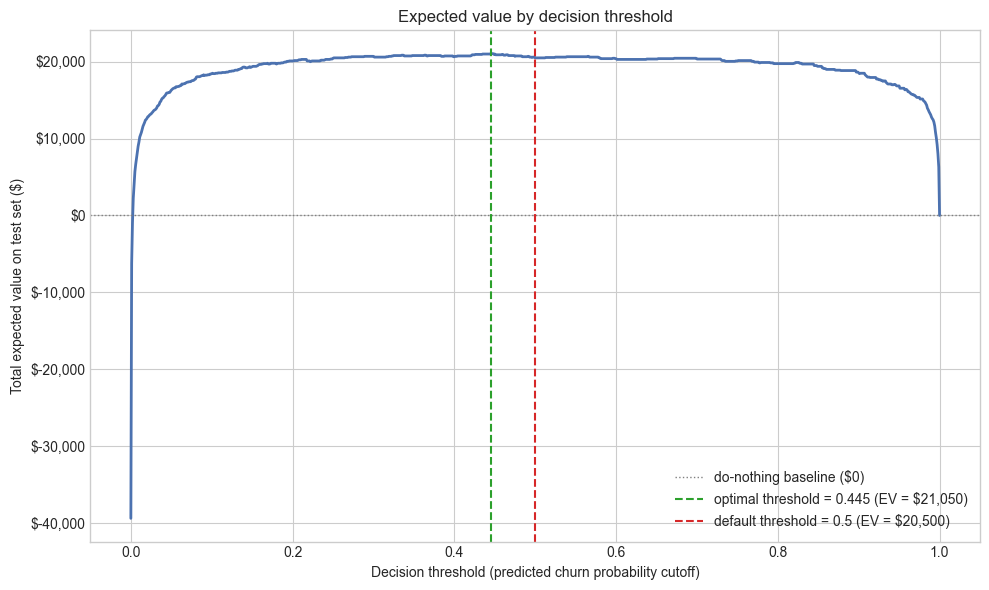

In [10]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(sweep["threshold"], sweep["ev"], linewidth=2)
ax.axhline(0, color="gray", linestyle=":", linewidth=1, label="do-nothing baseline ($0)")
ax.axvline(
    optimal_threshold, color="#2ca02c", linestyle="--", linewidth=1.5,
    label=f"optimal threshold = {optimal_threshold:.3f} (EV = ${optimal_ev:,.0f})",
)
ax.axvline(
    0.5, color="#d62728", linestyle="--", linewidth=1.5,
    label=f"default threshold = 0.5 (EV = ${ev_at_default:,.0f})",
)

ax.set_xlabel("Decision threshold (predicted churn probability cutoff)")
ax.set_ylabel("Total expected value on test set ($)")
ax.set_title("Expected value by decision threshold")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax.legend(loc="lower right")

plt.tight_layout()
plt.savefig("figures/expected_value_curve.png", dpi=120, bbox_inches="tight")
plt.show()

Reading the curve:

- **The optimum sits at threshold 0.445 with EV = $21,050**, slightly below the default 0.5. At the midpoint cost assumptions the cost-aware optimum happens to land close to where a thoughtless 0.5 cutoff would put you — but "close" is not "the same." The gap is +$550 on this test set (1,520 customers); annualized across a real portfolio of millions, that scales.
- **The peak is broad, not sharp.** Any threshold from roughly 0.27 to 0.58 lands within $500 of the optimum, and from 0.19 to 0.77 within $1,000. The recommendation is robust to small calibration error and to disagreement about the exact cost inputs.
- **Blanket offering is catastrophic.** At threshold 0 every customer is flagged and total EV is -$39,400. The cost of false positives on 1,276 non-churners overwhelms the LTV recaptured from 244 saves. This is the answer to the intuitive question "why not just offer everyone the discount?"
- **The right side asymptotes to $0,** which is the do-nothing baseline by construction. Above the optimum the threshold gets so restrictive that the model essentially stops acting, and EV converges back to the no-program baseline.

The small gap between optimum and default at midpoint assumptions is itself a finding worth being honest about — and it sets up the sensitivity analysis later, which will show how much that gap widens under plausible alternative values for offer cost, LTV, and the success rate.

## Strategy comparison

Four strategies are worth comparing head to head:

- **Optimal threshold (0.445)** — the EV-maximizing cutoff from the previous step.
- **Default threshold (0.5)** — what you get if you take the model's score at face value and never think about cost.
- **Do nothing** — no retention program at all. Every churner churns.
- **Blanket offer** — send a retention offer to every customer regardless of model score, with no targeting.

Total expected value of each is read directly from the cost-matrix-weighted confusion matrix on the test set. Normalizing per 1,000 customers gives a number that scales linearly to portfolios larger than this one.

In [11]:
N_TEST = len(y_test)
blanket_ev = sweep.loc[sweep["threshold"] == 0.0, "ev"].iloc[0]

strategies = pd.DataFrame(
    [
        ("Optimal threshold (0.445)", optimal_ev),
        ("Default threshold (0.5)", ev_at_default),
        ("Do nothing (no offers)", 0.0),
        ("Blanket offer (every customer)", blanket_ev),
    ],
    columns=["strategy", "total_ev"],
)
strategies["ev_per_customer"] = strategies["total_ev"] / N_TEST
strategies["ev_per_1000_customers"] = strategies["ev_per_customer"] * 1000

strategies.round(2)

,strategy,total_ev,ev_per_customer,ev_per_1000_customers
0,Optimal threshold (0.445),21050.0,13.85,13848.68
1,Default threshold (0.5),20500.0,13.49,13486.84
2,Do nothing (no offers),0.0,0.00,0.00
3,Blanket offer (every customer),-39400.0,-25.92,-25921.05


Two gaps are worth surfacing:

- **Optimal vs the best no-model alternative.** Among the strategies that don't use the model at all — do nothing and blanket offer — the better one is do nothing ($0). The optimal strategy beats that by **$21,050 on the test set, or $13,849 per 1,000 customers**. This is the value of running a targeted retention program at all.
- **Optimal vs default 0.5.** Among the strategies that do use the model, the cost-aware optimum beats the default-threshold strategy by **$550 on the test set, or $362 per 1,000 customers**. Smaller, but it's free — same model, same data, just a different cutoff.

And blanket offering — the gut-feel "let's just try to save everyone" approach — costs **-$25,921 per 1,000 customers** vs doing nothing. The next step walks through *why* a no-targeting program ends up worse than no program at all.

## Business interpretation

At midpoint cost assumptions ($50 offer / $500 LTV / 30% success rate), the EV-optimal decision threshold on this test set is **0.445**, delivering **$21,050 in expected value across 1,520 customers** (~$13,849 per 1,000). That's $362 per 1,000 better than the default 0.5 threshold and $13,849 per 1,000 better than not running a retention program at all. Blanket offering — the gut-check "save everyone" strategy — destroys $25,921 per 1,000.

### Why blanket offering is worse than doing nothing

Trace the math. A blanket campaign pays $50 to all 1,520 customers — **$76,000 in total offer cost** — to save the ~73 churners that a 30% success rate predicts the program will recover from the 244 real churners in the test set. Those saves return 73 × $500 = **$36,500 in recaptured LTV**. Net result: spend $76,000 to recover $36,500, leaving a $39,500 hole.

Said differently: each saved customer costs the bank **about $1,040 to acquire back — more than twice their $500 lifetime value**. The cost of carrying 1,276 false positives swamps the program.

This is the central insight of cost-aware thresholding. False positives are not free, and a strategy that flags everyone has the worst possible precision (the population's base churn rate, 16%). Even a perfect intervention can't pay back the cost of acting on every non-churner.

### Why the optimal threshold beats default 0.5

Both thresholds apply to the same model. At the optimum (0.445) the model flags 263 customers — 228 true positives and 35 false positives. At the default (0.5) it flags 247 — 219 TPs and 28 FPs. Lowering the threshold from 0.5 to 0.445 trades **9 extra true positives for 7 extra false positives**, gaining 9 × $100 − 7 × $50 = **$550 in marginal expected value**.

The rule generalizes: at this cost ratio, lowering the threshold pays off whenever the next candidates the model wants to flag include at least one true positive for every two false positives (a 33% marginal precision). The optimum sits exactly where that ratio breaks even.

The gap over default is small here ($550) because the model is well-calibrated near 0.5 and the cost ratio happens to put the breakeven point close to it. The sensitivity analysis later in this notebook is where the framework's value gets tested under conditions that move the optimum further from the default.

## Per-segment optimal thresholds

A single global threshold treats every customer as if their cost-benefit profile is the same. It isn't. From the EDA, churn rate varies several-fold across activity segments — low-activity customers churn at over 30%, high-activity customers near 2%. Tenure showed weaker signal in Phase 2, but the cross-segment heatmap still revealed some heterogeneity. The right way to check whether one threshold fits all is to recompute the EV sweep within each segment and see where its peak lands.

I reuse the same two segmentations from Phase 3: tenure tier (qcut of `Months_on_book` into 3 buckets) and activity tier (qcut of `Total_Trans_Ct` into 3 buckets). The qcut runs on the test set directly rather than reloading the full dataset for bin edges — the test set is a 15% stratified slice, so the tier boundaries land within a customer or two of the Phase 3 ones.

In [12]:
test_seg = X_test.copy()
test_seg["tenure_segment"] = pd.qcut(
    test_seg["Months_on_book"], q=3, labels=["New", "Established", "Long-tenured"]
)
test_seg["activity_segment"] = pd.qcut(
    test_seg["Total_Trans_Ct"], q=3, labels=["Low", "Medium", "High"]
)

test_seg[["tenure_segment", "activity_segment"]].apply(lambda s: s.value_counts(sort=False))

,tenure_segment,activity_segment
Established,529.0,NaN
High,NaN,505.0
Long-tenured,466.0,NaN
Low,NaN,507.0
Medium,NaN,508.0
New,525.0,NaN


In [13]:
def find_segment_optimum(mask):
    """Return (optimal_threshold, ev_at_optimum, ev_at_global) for the masked subset of the test set."""
    p = probs[mask]
    y = y_test[mask].values

    rows = []
    for t in thresholds:
        preds = (p >= t).astype(int)
        tn, fp, fn, tp = confusion_matrix(y, preds, labels=[0, 1]).ravel()
        ev = tp * cost_matrix["TP"] + fp * cost_matrix["FP"]
        rows.append((t, ev))
    seg_sweep = pd.DataFrame(rows, columns=["threshold", "ev"])

    best = seg_sweep.loc[seg_sweep["ev"].idxmax()]
    ev_at_global = seg_sweep.loc[seg_sweep["threshold"] == optimal_threshold, "ev"].iloc[0]

    return best["threshold"], best["ev"], ev_at_global


segment_rows = []
for dim in ["tenure_segment", "activity_segment"]:
    for value in test_seg[dim].cat.categories:
        mask = (test_seg[dim] == value).values
        n = int(mask.sum())
        churn_rate = float(y_test[mask].mean())
        opt_t, ev_opt, ev_global = find_segment_optimum(mask)
        segment_rows.append({
            "dimension": dim.replace("_segment", ""),
            "segment": value,
            "n": n,
            "churn_rate": churn_rate,
            "optimal_threshold": opt_t,
            "ev_at_segment_opt": ev_opt,
            "ev_at_global_opt": ev_global,
        })

segment_results = pd.DataFrame(segment_rows)
segment_results["gap"] = segment_results["ev_at_segment_opt"] - segment_results["ev_at_global_opt"]
segment_results.round(3)

,dimension,segment,n,churn_rate,optimal_threshold,ev_at_segment_opt,ev_at_global_opt,gap
0,tenure,New,525,0.135,0.450,5750.0,5700.0,50.0
1,tenure,Established,529,0.181,0.426,8500.0,8500.0,0.0
2,tenure,Long-tenured,466,0.165,0.323,7000.0,6850.0,150.0
3,activity,Low,507,0.361,0.445,16300.0,16300.0,0.0
4,activity,Medium,508,0.098,0.599,4100.0,3850.0,250.0
5,activity,High,505,0.022,0.273,1000.0,900.0,100.0


In [14]:
tenure_gain = segment_results.loc[segment_results["dimension"] == "tenure", "gap"].sum()
activity_gain = segment_results.loc[segment_results["dimension"] == "activity", "gap"].sum()
global_ev = sweep.loc[sweep["threshold"] == optimal_threshold, "ev"].iloc[0]

pd.DataFrame(
    [
        ("Tenure-based per-segment thresholds", tenure_gain, 100 * tenure_gain / global_ev),
        ("Activity-based per-segment thresholds", activity_gain, 100 * activity_gain / global_ev),
    ],
    columns=["segmentation", "ev_gain_vs_global", "lift_pct"],
).round(2)

,segmentation,ev_gain_vs_global,lift_pct
0,Tenure-based per-segment thresholds,200.0,0.95
1,Activity-based per-segment thresholds,350.0,1.66


What the segment table shows:

- **Segment optima do vary**, but not as cleanly as the EDA churn-rate disparities might suggest. Within tenure, all three optima sit within 0.12 of the global 0.445; within activity, the range is wider (0.273 to 0.599), but the High-activity row is driven by only 11 real churners and the optimum it picks is more sampling noise than signal at that sample size.
- **The gain from per-segment thresholding is small.** A tenure-based regime adds about $200 over the global threshold on this test set (a ~1% lift); an activity-based regime adds about $350 (~1.7%). The two dimensions can't be summed naively because every customer belongs to both — the comparison is choose-one, not stack-both. Either way the per-segment win is dwarfed by the $21K of value that the targeting program itself generates.
- **Why the gain is small:** the EV curve was already broad at the global level — any threshold in roughly [0.27, 0.58] lands within $500 of the global optimum. Within most segments, the same broad plateau holds, so picking the segment-specific optimum doesn't move EV much beyond what the global threshold already captures.

Strategically, the global threshold is a defensible starting point for deployment. Per-segment tuning is a real second-order optimization, but not the first knob to turn. It earns its keep under two conditions worth naming explicitly: if the cost inputs themselves vary across segments (a Long-tenured customer's LTV is plausibly higher than a New one's, which this analysis assumed constant), or if the cost assumptions move into a regime where the global threshold sits further from the segment optima — the next step tests exactly that kind of shift.

## Sensitivity analysis: design

The optimum at midpoint assumptions is one point in a three-dimensional input space. Sensitivity analysis answers: how much does the recommendation move when each input is wrong? Which one would I want to measure most carefully in production?

**Methodology.** Vary each of the three inputs independently across a generous range, holding the other two at their midpoint. At each variation, recompute the optimal threshold and the expected value at that optimum. Two outputs per input (threshold drift, EV at optimum) give six curves total when plotted in Step 10.

I vary the inputs independently, not jointly, for two reasons. First, the leadership question is "which assumption should we measure most carefully?" — a per-input question. Second, a joint three-way sweep blows up the visualization and hides which input is doing the work.

**Ranges.**

- **Offer cost: $20 to $100 in $5 steps** (17 points). Brackets the published $25–$100 range with a small extension below.
- **Customer LTV: $200 to $1,000 in $50 steps** (17 points). Covers 0.4× to 2× the midpoint — wide enough to absorb both segment-level LTV variation and uncertainty about whether $500 is the right anchor.
- **Offer success rate: 10% to 50% in 2.5% steps** (17 points). Brackets the published 20–40% range on both sides. This is the most uncertain input, so it gets the widest relative sweep.

**A faster sweep.** Each recomputation only needs the TP and FP counts at every threshold, which the global `sweep` DataFrame already has. For any cost matrix, total EV at a threshold is just `tp × cost["TP"] + fp × cost["FP"]` — a single multiplication-and-add over a 1,001-row Series. The helper below uses that shortcut, so the full sensitivity sweep below runs in milliseconds rather than re-fitting confusion matrices.

In [15]:
OFFER_COST_RANGE = np.arange(20, 105, 5)
LTV_RANGE = np.arange(200, 1050, 50)
SUCCESS_RATE_RANGE = np.linspace(0.10, 0.50, 17)

OFFER_COST_RANGE.shape, LTV_RANGE.shape, SUCCESS_RATE_RANGE.shape

((17,), (17,), (17,))

In [16]:
def find_optimum_with_costs(offer_cost, customer_ltv, offer_success_rate):
    """Return (optimal_threshold, ev_at_optimum) for a given cost-assumption set."""
    cost = build_cost_matrix(offer_cost, customer_ltv, offer_success_rate)
    evs = sweep["tp"] * cost["TP"] + sweep["fp"] * cost["FP"]
    best_idx = evs.idxmax()
    return float(sweep.loc[best_idx, "threshold"]), float(evs[best_idx])

# Sanity check at midpoint — should reproduce the global optimum and EV from Step 5.
find_optimum_with_costs(OFFER_COST, CUSTOMER_LTV, OFFER_SUCCESS_RATE)

(0.445, 21050.0)

## Sensitivity sweep results

Running the sweep is now a single pass per input. Each row of `sensitivity` records the input being varied, the value it takes, and the resulting optimal threshold and EV at that optimum. All three sweeps share the same shape (17 rows each, 51 rows total).

In [17]:
sensitivity_rows = []

for cost_val in OFFER_COST_RANGE:
    t, ev = find_optimum_with_costs(cost_val, CUSTOMER_LTV, OFFER_SUCCESS_RATE)
    sensitivity_rows.append({"input": "offer_cost", "value": cost_val, "optimal_threshold": t, "ev_at_optimum": ev})

for ltv_val in LTV_RANGE:
    t, ev = find_optimum_with_costs(OFFER_COST, ltv_val, OFFER_SUCCESS_RATE)
    sensitivity_rows.append({"input": "ltv", "value": ltv_val, "optimal_threshold": t, "ev_at_optimum": ev})

for rate_val in SUCCESS_RATE_RANGE:
    t, ev = find_optimum_with_costs(OFFER_COST, CUSTOMER_LTV, rate_val)
    sensitivity_rows.append({"input": "success_rate", "value": rate_val, "optimal_threshold": t, "ev_at_optimum": ev})

sensitivity = pd.DataFrame(sensitivity_rows)
sensitivity.groupby("input").agg(
    threshold_min=("optimal_threshold", "min"),
    threshold_max=("optimal_threshold", "max"),
    ev_min=("ev_at_optimum", "min"),
    ev_max=("ev_at_optimum", "max"),
).round(2)

,threshold_min,threshold_max,ev_min,ev_max
input,,,,
ltv,0.21,0.82,1450.0,55700.0
offer_cost,0.21,0.82,9050.0,29360.0
success_rate,0.34,1.00,0.0,44050.0


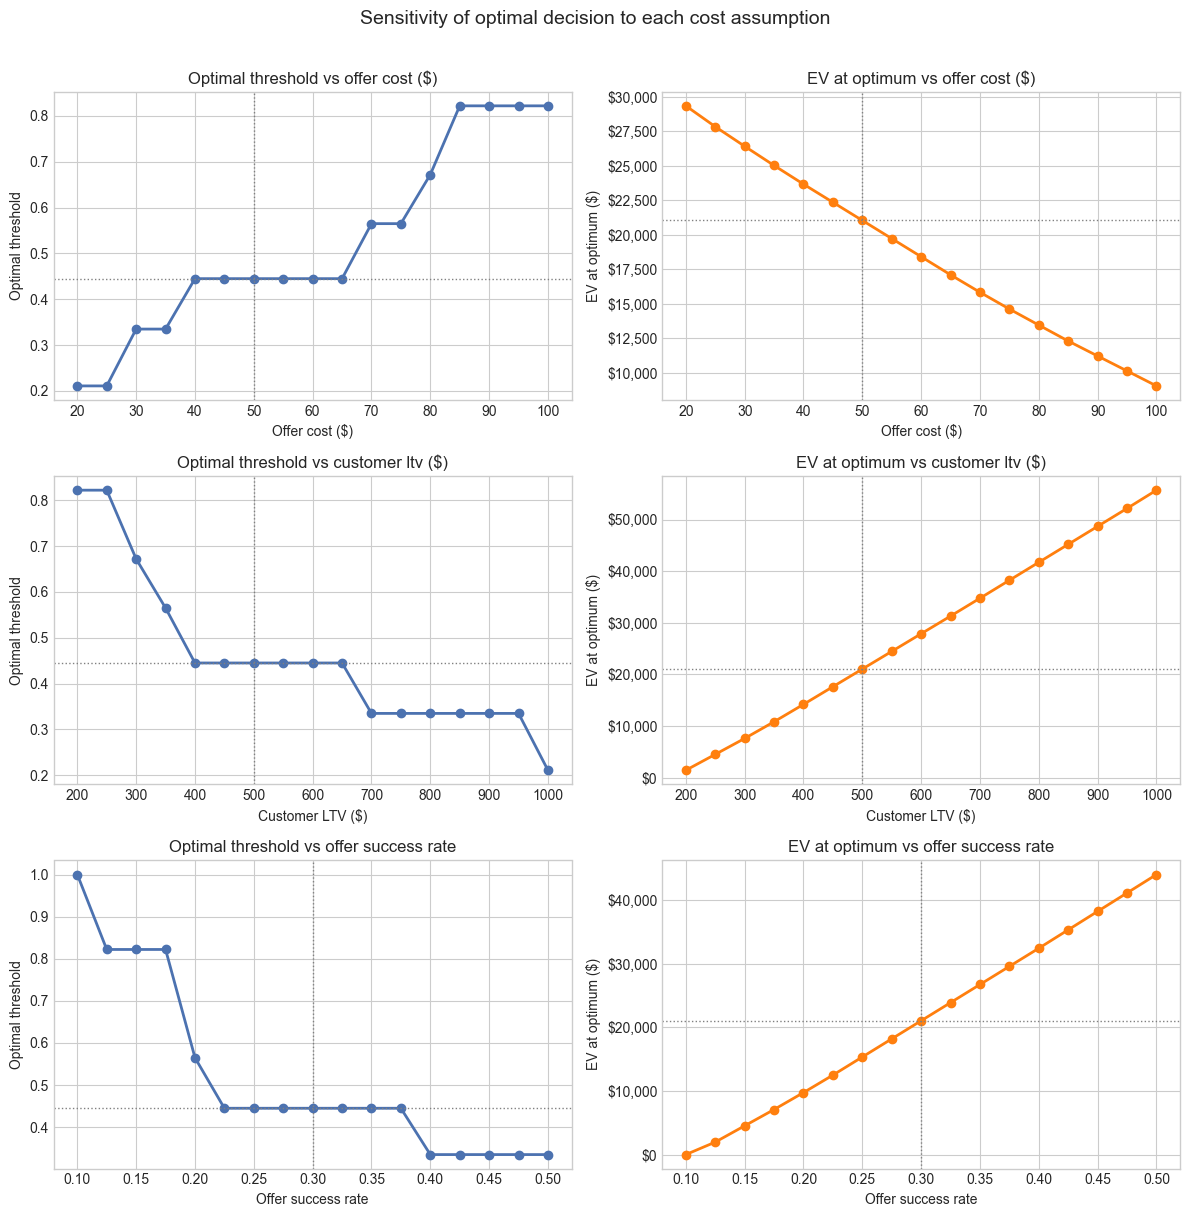

In [18]:
fig, axes = plt.subplots(3, 2, figsize=(12, 12))

inputs = [
    ("offer_cost", "Offer cost ($)", OFFER_COST),
    ("ltv", "Customer LTV ($)", CUSTOMER_LTV),
    ("success_rate", "Offer success rate", OFFER_SUCCESS_RATE),
]

for row, (key, xlabel, midpoint) in enumerate(inputs):
    sub = sensitivity[sensitivity["input"] == key]

    ax_t = axes[row, 0]
    ax_t.plot(sub["value"], sub["optimal_threshold"], marker="o", linewidth=2)
    ax_t.axvline(midpoint, color="gray", linestyle=":", linewidth=1)
    ax_t.axhline(optimal_threshold, color="gray", linestyle=":", linewidth=1)
    ax_t.set_xlabel(xlabel)
    ax_t.set_ylabel("Optimal threshold")
    ax_t.set_title(f"Optimal threshold vs {xlabel.lower()}")

    ax_v = axes[row, 1]
    ax_v.plot(sub["value"], sub["ev_at_optimum"], marker="o", linewidth=2, color="#ff7f0e")
    ax_v.axvline(midpoint, color="gray", linestyle=":", linewidth=1)
    ax_v.axhline(optimal_ev, color="gray", linestyle=":", linewidth=1)
    ax_v.set_xlabel(xlabel)
    ax_v.set_ylabel("EV at optimum ($)")
    ax_v.set_title(f"EV at optimum vs {xlabel.lower()}")
    ax_v.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x:,.0f}"))

fig.suptitle("Sensitivity of optimal decision to each cost assumption", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("figures/sensitivity_analysis.png", dpi=120, bbox_inches="tight")
plt.show()

## What the sensitivity sweep says — the robustness narrative

Three findings, in order of strategic importance.

### The optimal threshold is not robust to any of the three inputs

Across the swept ranges the optimal threshold moves substantially in every case:

- **Offer cost $20 → $100:** optimum rises from 0.21 to 0.82.
- **Customer LTV $200 → $1,000:** optimum falls from 0.82 to 0.21.
- **Success rate 10% → 50%:** optimum falls from 1.00 (don't act) to 0.34.

The midpoint optimum at 0.445 is the right answer only for the midpoint inputs. The value of the cost-aware framework isn't a single number; it's a function that maps any input configuration to the right cutoff. A team running this in production needs to pick a threshold *for the inputs they have* — and they should expect to revisit that choice whenever their measurements update.

### LTV moves total EV the most; offer cost moves it the least

EV at optimum ranges across each swept input:

- **LTV:** $1,450 → $55,700 — a $54K range.
- **Success rate:** $0 → $44,050 — a $44K range.
- **Offer cost:** $9,050 → $29,360 — a $20K range.

LTV scales the gain side of every successful save linearly, and the swept range covers 0.4× to 2× the midpoint, so the EV magnitude swings dramatically. Offer cost moves both the gain side (via the TP cell) and the loss side (via the FP cell), and the two partially cancel — getting it wrong by 50% still leaves a profitable program.

### There is a hard cliff in the success rate

The most operationally important finding: at a success rate of about 10%, the TP-cell expected value collapses to zero (0.10 × $500 = $50 = offer cost). Below that point no threshold can make the program profitable — the optimum becomes "flag nobody," EV = $0. This is a discontinuity, not a gradient. The difference between a 15% success rate and a 9% success rate is the difference between a working retention program and one that should be canceled before launch.

## What this means for production deployment

If a team had measurement budget for only one of these three inputs before going live, the answer is **success rate**. Three reasons:

1. **Wrong-side-of-cliff risk.** A small error on LTV or offer cost leaves the program profitable; a small error on success rate near the cliff (sitting at 12% when reality is 8%) means deploying a value-destructive program.
2. **Highest per-unit EV sensitivity.** A one-percentage-point change in the success rate moves total EV by roughly $1,100 on this test set.
3. **It is also the input the dataset gives us the least direct evidence about.** The dataset has no record of past retention offers, so the 30% midpoint is borrowed from industry benchmarks rather than measured.

The natural way to measure it is a small randomized hold-out: route a fraction of model-flagged customers around the offer, run both arms for a quarter, and compare realized churn rates. This is a small experiment, not a years-long study.

**LTV is second priority.** Existing customer-revenue data can be used to back into a per-segment estimate, refining the uniform-LTV assumption used here. The fact that LTV is the biggest EV mover also makes the case for disaggregating it across customer segments — a Long-tenured customer's LTV is almost certainly higher than a New customer's, and applying segment-specific values would change the per-segment thresholds in Step 8 meaningfully.

**Offer cost is the least urgent.** It moves EV the least and is the most directly observable from existing operational data. Even a 50% miscalibration here leaves the program profitable.

## The honest headline, revisited

At midpoint assumptions the cost-aware optimum beat default 0.5 by $550 — a small number, and one I called out as such in the business interpretation. The sensitivity analysis is where the framework earns its keep. Under inputs that the bank could plausibly have, the optimum sits anywhere from 0.21 to 1.0; the default-vs-optimum gap can be far larger than $550 in either direction; and the program itself is profitable or unprofitable depending on a single input the dataset doesn't observe. The value of this analysis isn't the $550. It's producing the right cutoff for the bank's real inputs, and surfacing the one input they need to measure precisely before deploying.